This project aims to predict whether a borrower will repay or default on a loan using historical Lending Club data.

The project includes:

• Exploratory Data Analysis
• Data Cleaning
• Feature Engineering
• Model Building
• Model Comparison
• Performance Evaluation

Three supervised learning models were developed and compared:
• Logistic Regression
• Random Forest
• Neural Network

Dataset

Source:
Lending Club Loan Dataset

Target Variable:
loan_repaid

Features include:

• Loan Amount
• Interest Rate
• Annual Income
• Employment Length
• Home Ownership
• Debt-to-Income Ratio
• Credit Grade

In [1]:
import pandas as pd

In [2]:
data_info = pd.read_csv('datasets\lending_club_info.csv',index_col='LoanStatNew')

In [3]:
def feat_info(col_name):
    print(data_info.loc[col_name]['Description'])

In [4]:
feat_info('mort_acc')

Number of mortgage accounts.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
df = pd.read_csv('datasets/lending_club_loan_two.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

EDA

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


<Axes: xlabel='loan_status', ylabel='count'>

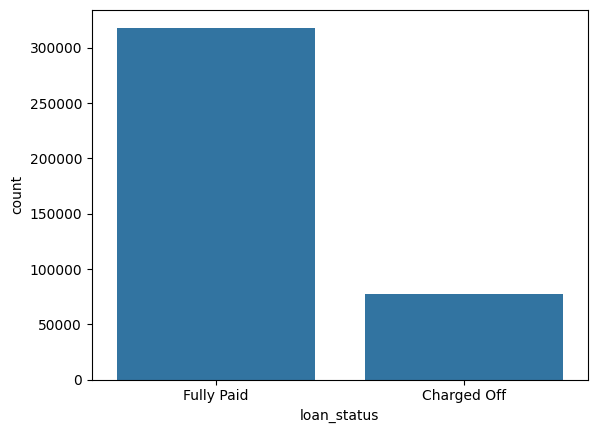

In [8]:
sns.countplot(data=df, x='loan_status')

C:\Users\srisa\AppData\Local\Temp\ipykernel_9892\2022642379.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['loan_amnt'],kde=False,bins=40)


(0.0, 45000.0)

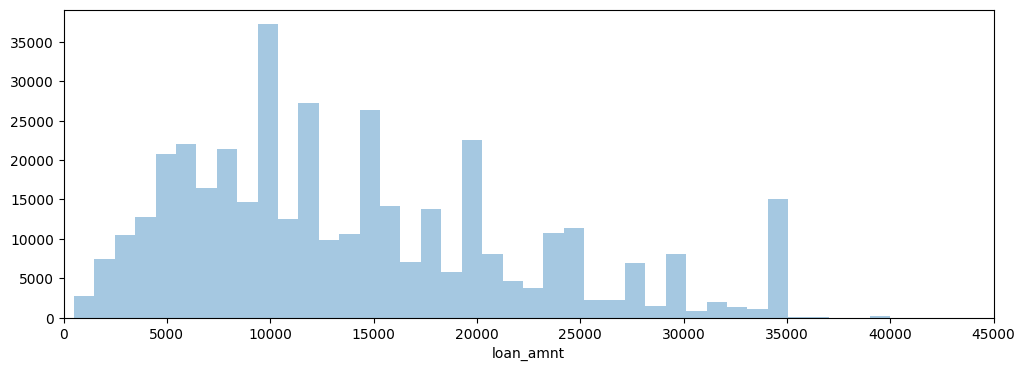

In [9]:
plt.figure(figsize=(12,4))
sns.distplot(df['loan_amnt'],kde=False,bins=40)
plt.xlim(0,45000)

<Axes: xlabel='loan_amnt', ylabel='Count'>

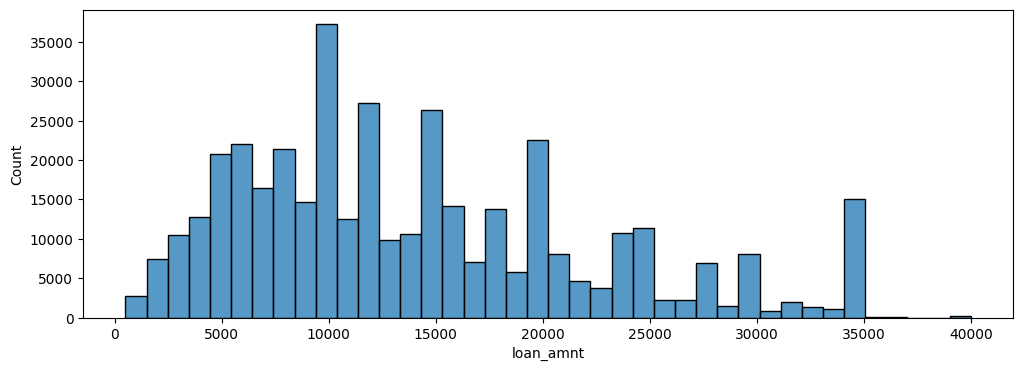

In [10]:
plt.figure(figsize=(12,4))
sns.histplot(data=df,x='loan_amnt', kde=False,bins=40)

In [11]:
# CODE HERE
df.corr(numeric_only=True)

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
loan_amnt,1.000000,0.168921,0.953929,0.336887,0.016636,0.198556,-0.077779,0.328320,0.099911,0.223886,0.222315,-0.106539
int_rate,0.168921,1.000000,0.162758,-0.056771,0.079038,0.011649,0.060986,-0.011280,0.293659,-0.036404,-0.082583,0.057450
installment,0.953929,0.162758,1.000000,0.330381,0.015786,0.188973,-0.067892,0.316455,0.123915,0.202430,0.193694,-0.098628
annual_inc,0.336887,-0.056771,0.330381,1.000000,-0.081685,0.136150,-0.013720,0.299773,0.027871,0.193023,0.236320,-0.050162
dti,0.016636,0.079038,0.015786,-0.081685,1.000000,0.136181,-0.017639,0.063571,0.088375,0.102128,-0.025439,-0.014558
open_acc,0.198556,0.011649,0.188973,0.136150,0.136181,1.000000,-0.018392,0.221192,-0.131420,0.680728,0.109205,-0.027732
pub_rec,-0.077779,0.060986,-0.067892,-0.013720,-0.017639,-0.018392,1.000000,-0.101664,-0.075910,0.019723,0.011552,0.699408
revol_bal,0.328320,-0.011280,0.316455,0.299773,0.063571,0.221192,-0.101664,1.000000,0.226346,0.191616,0.194925,-0.124532
revol_util,0.099911,0.293659,0.123915,0.027871,0.088375,-0.131420,-0.075910,0.226346,1.000000,-0.104273,0.007514,-0.086751
total_acc,0.223886,-0.036404,0.202430,0.193023,0.102128,0.680728,0.019723,0.191616,-0.104273,1.000000,0.381072,0.042035


<Axes: >

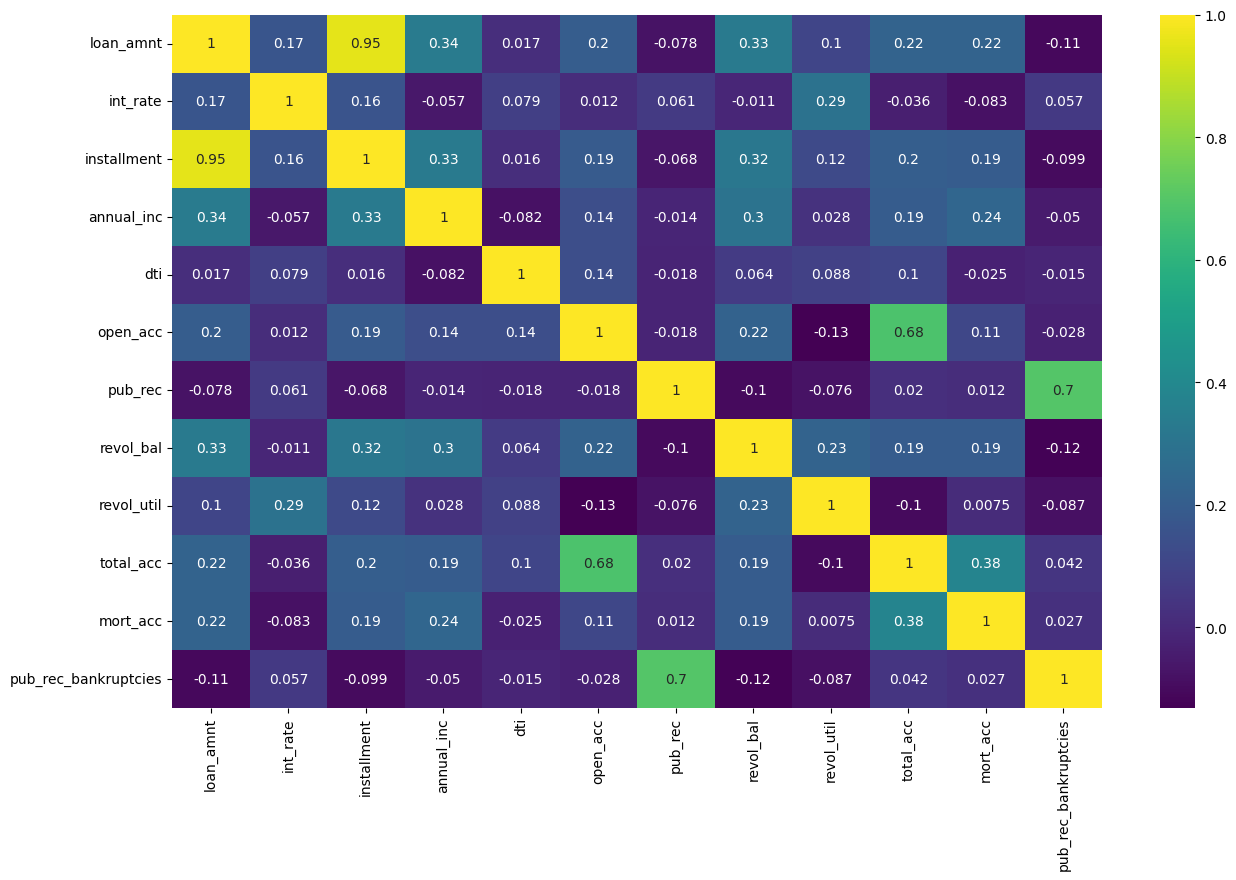

In [12]:
plt.figure(figsize=(15,9))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='viridis')

In [13]:
feat_info('installment')

The monthly payment owed by the borrower if the loan originates.


In [14]:
feat_info('loan_amnt')

The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.


<Axes: xlabel='installment', ylabel='loan_amnt'>

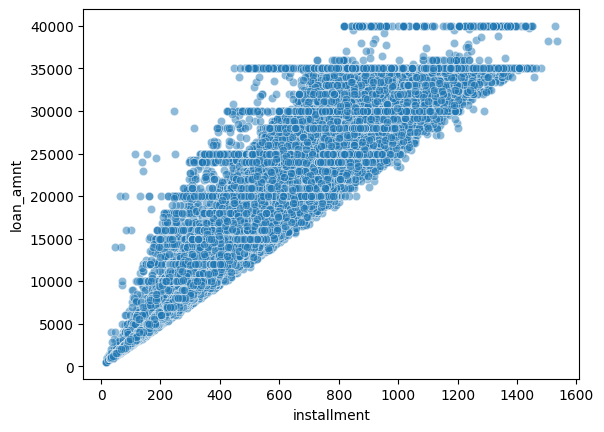

In [15]:
sns.scatterplot(data=df,x='installment',y='loan_amnt', alpha= 0.5)

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='loan_status', ylabel='loan_amnt'>

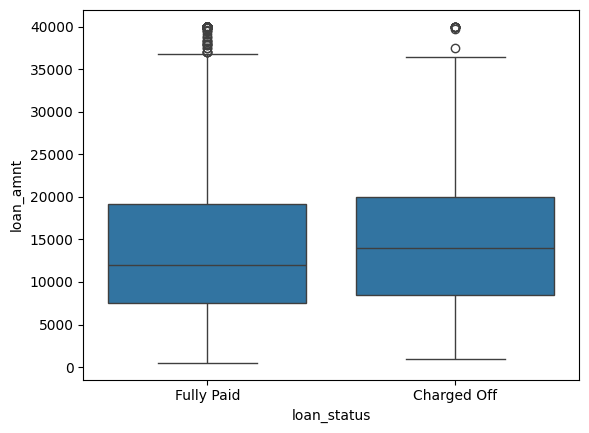

In [16]:
sns.boxplot(x='loan_status',y='loan_amnt', data=df)

In [17]:
df.groupby('loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,77673.0,15126.300967,8505.090557,1000.0,8525.0,14000.0,20000.0,40000.0
Fully Paid,318357.0,13866.878771,8302.319699,500.0,7500.0,12000.0,19225.0,40000.0


In [18]:
feat_info('sub_grade')

LC assigned loan subgrade


In [19]:
feat_info('grade')

LC assigned loan grade


In [20]:
df['sub_grade'].unique()

array(['B4', 'B5', 'B3', 'A2', 'C5', 'C3', 'A1', 'B2', 'C1', 'A5', 'E4',
       'A4', 'A3', 'D1', 'C2', 'B1', 'D3', 'D5', 'D2', 'E1', 'E2', 'E5',
       'F4', 'E3', 'D4', 'G1', 'F5', 'G2', 'C4', 'F1', 'F3', 'G5', 'G4',
       'F2', 'G3'], dtype=object)

In [21]:
df['grade'].unique()

array(['B', 'A', 'C', 'E', 'D', 'F', 'G'], dtype=object)

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.

<Axes: xlabel='grade', ylabel='count'>

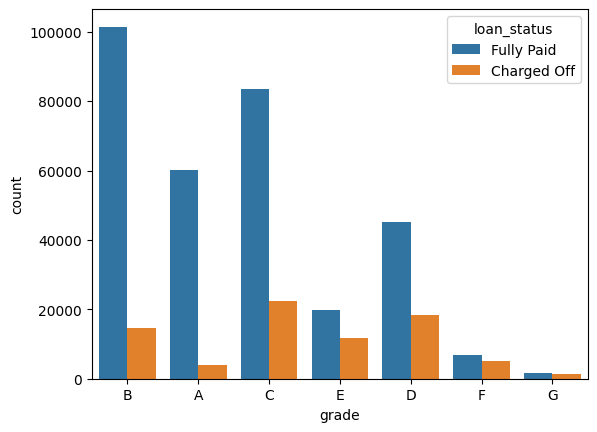

In [22]:
sns.countplot(data=df, x='grade',
              hue='loan_status')

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.

<Axes: xlabel='sub_grade', ylabel='count'>

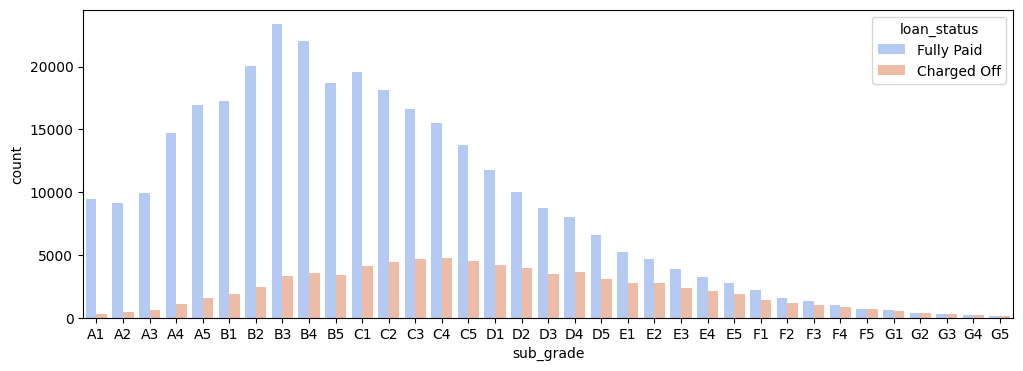

In [23]:
plt.figure(figsize=(12,4))
subgrade_order = sorted(df['sub_grade'].unique())
sns.countplot(data=df,x='sub_grade',
              order=subgrade_order,
              palette='coolwarm',
              hue='loan_status'
              )

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.

<Axes: xlabel='sub_grade', ylabel='count'>

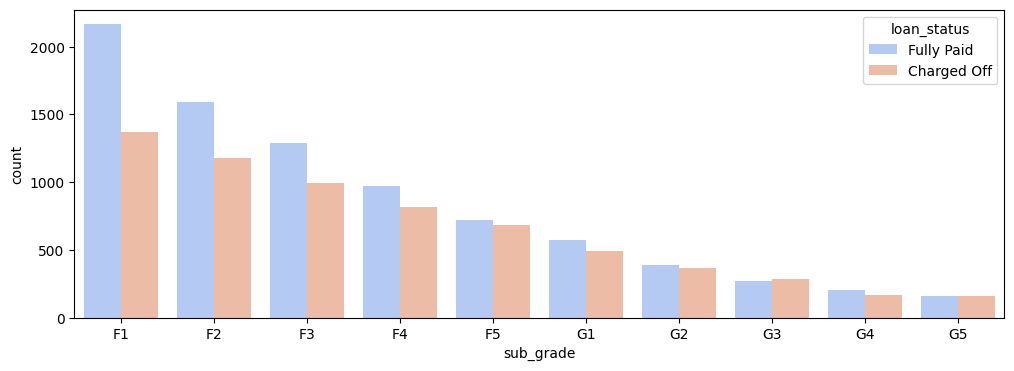

In [24]:
f_and_g = df[(df['grade']=='G') | (df['grade']=='F')]

plt.figure(figsize=(12,4))
subgrade_order = sorted(f_and_g['sub_grade'].unique())
sns.countplot(data=f_and_g,x='sub_grade',
              order=subgrade_order,
              palette='coolwarm',
              hue='loan_status'
              )

In [25]:
df['loan_repaid']=df['loan_status'].map({"Fully Paid":1,'Charged Off':0})

In [26]:
df[['loan_repaid','loan_status']]

,loan_repaid,loan_status
0,1,Fully Paid
1,1,Fully Paid
2,1,Fully Paid
3,1,Fully Paid
4,0,Charged Off
...,...,...
396025,1,Fully Paid
396026,1,Fully Paid
396027,1,Fully Paid
396028,1,Fully Paid


<Axes: >

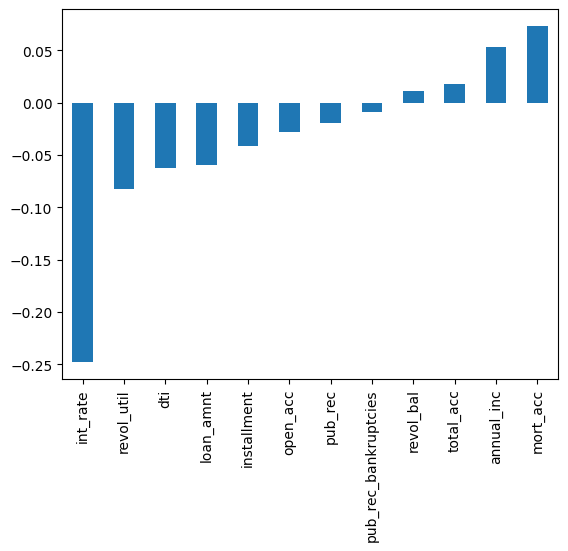

In [27]:
df.corr(numeric_only=True)['loan_repaid'][:-1].sort_values().plot(kind='bar')

<Axes: >

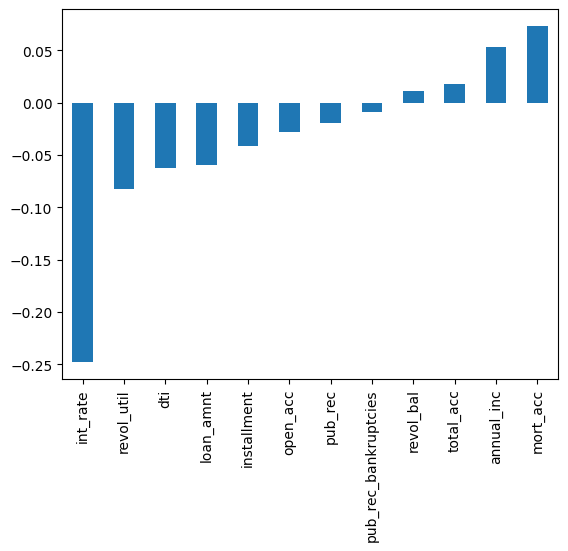

In [28]:
#sns.barplot(data=df,x=df.corr(numeric_only=True)['loan_repaid'])
df.corr(numeric_only=True)['loan_repaid'][:-1].sort_values().plot(kind='bar')

Data Preprocessing

In [29]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address,loan_repaid
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690",1
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113",1
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113",1
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813",1
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650",0


In [30]:
len(df)

396030

In [31]:
df.isnull().sum()

loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
emp_title               22927
emp_length              18301
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
loan_repaid                 0
dtype: int64

In [32]:
df.isnull().sum()/len(df)*100

loan_amnt               0.000000
term                    0.000000
int_rate                0.000000
installment             0.000000
grade                   0.000000
sub_grade               0.000000
emp_title               5.789208
emp_length              4.621115
home_ownership          0.000000
annual_inc              0.000000
verification_status     0.000000
issue_d                 0.000000
loan_status             0.000000
purpose                 0.000000
title                   0.443401
dti                     0.000000
earliest_cr_line        0.000000
open_acc                0.000000
pub_rec                 0.000000
revol_bal               0.000000
revol_util              0.069692
total_acc               0.000000
initial_list_status     0.000000
application_type        0.000000
mort_acc                9.543469
pub_rec_bankruptcies    0.135091
address                 0.000000
loan_repaid             0.000000
dtype: float64

In [33]:
feat_info('emp_length')

Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. 


In [34]:
feat_info('emp_title')

The job title supplied by the Borrower when applying for the loan.*


In [35]:
df['emp_title'].nunique()

173105

In [36]:
df['emp_title'].value_counts()

emp_title
Teacher                    4389
Manager                    4250
Registered Nurse           1856
RN                         1846
Supervisor                 1830
                           ... 
Postman                       1
McCarthy & Holthus, LLC       1
jp flooring                   1
Histology Technologist        1
Gracon Services, Inc          1
Name: count, Length: 173105, dtype: int64

In [37]:
df = df.drop('emp_title',axis=1)

In [38]:
sorted(df['emp_length'].dropna().unique())

['1 year',
 '10+ years',
 '2 years',
 '3 years',
 '4 years',
 '5 years',
 '6 years',
 '7 years',
 '8 years',
 '9 years',
 '< 1 year']

In [39]:
emp_length_order = ['< 1 year',
 '1 year',
 '2 years',
 '3 years',
 '4 years',
 '5 years',
 '6 years',
 '7 years',
 '8 years',
 '9 years',
 '10+ years',
 ]

C:\Users\srisa\AppData\Local\Temp\ipykernel_9892\3153493182.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emp_length',order=emp_length_order,
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a futu

<Axes: xlabel='emp_length', ylabel='count'>

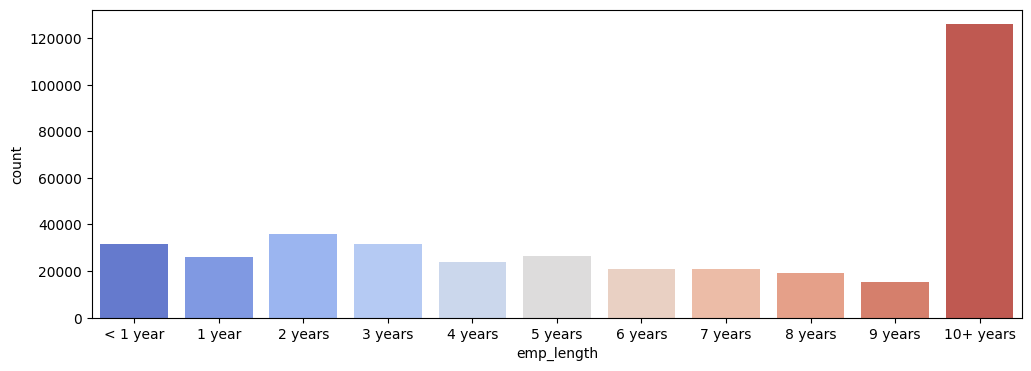

In [40]:
plt.figure(figsize=(12,4))
sns.countplot(data=df, x='emp_length',order=emp_length_order,
              palette='coolwarm',
              )

C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.

<Axes: xlabel='emp_length', ylabel='count'>

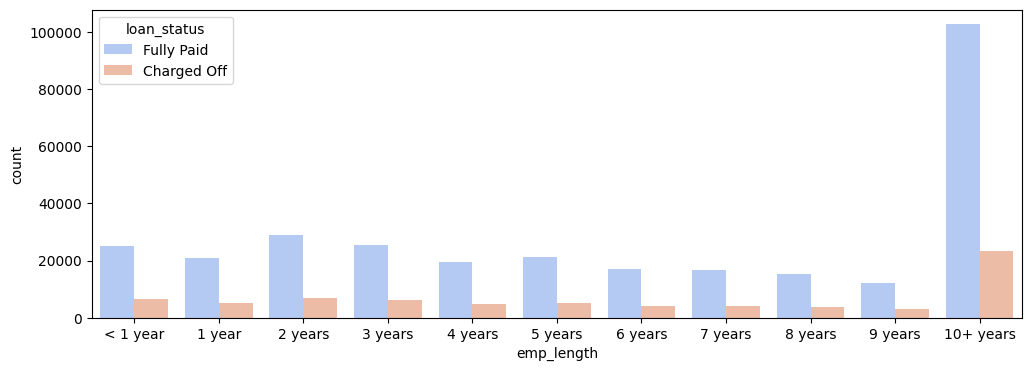

In [41]:
plt.figure(figsize=(12,4))
sns.countplot(data=df, x='emp_length',order=emp_length_order,
              palette='coolwarm',
              hue='loan_status'
              )

In [42]:
emp_co = df[df['loan_status']=='Charged Off'].groupby('emp_length').count()['loan_status']

In [43]:
emp_fp = df[df['loan_status']=='Fully Paid'].groupby('emp_length').count()['loan_status']

In [44]:
emp_len = emp_co/(emp_fp+emp_co)

<Axes: xlabel='emp_length'>

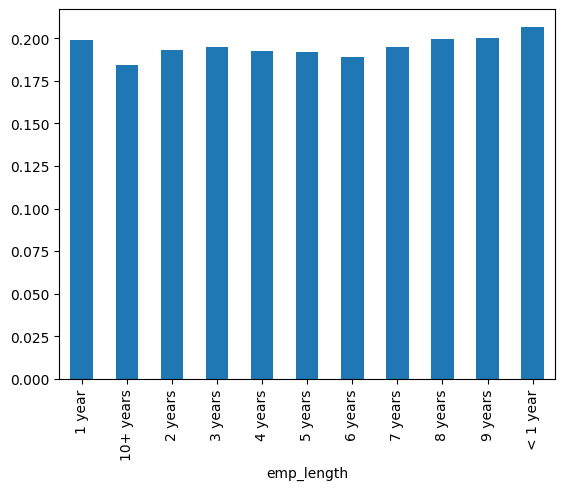

In [45]:
emp_len.plot(kind='bar')

In [46]:
df = df.drop('emp_length', axis =1)

In [47]:
df.isnull().sum()

loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
loan_status                 0
purpose                     0
title                    1756
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                276
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                37795
pub_rec_bankruptcies      535
address                     0
loan_repaid                 0
dtype: int64

In [48]:
df['purpose'].head(10)

0              vacation
1    debt_consolidation
2           credit_card
3           credit_card
4           credit_card
5    debt_consolidation
6      home_improvement
7           credit_card
8    debt_consolidation
9    debt_consolidation
Name: purpose, dtype: object

In [49]:
feat_info('purpose')

A category provided by the borrower for the loan request. 


In [50]:
feat_info('title')

The loan title provided by the borrower


In [51]:
df['title'].head(10)

0                   Vacation
1         Debt consolidation
2    Credit card refinancing
3    Credit card refinancing
4      Credit Card Refinance
5         Debt consolidation
6           Home improvement
7       No More Credit Cards
8         Debt consolidation
9         Debt Consolidation
Name: title, dtype: object

In [52]:
df = df.drop('title', axis=1)

In [53]:
feat_info("mort_acc")

Number of mortgage accounts.


In [54]:
df['mort_acc'].value_counts()

mort_acc
0.0     139777
1.0      60416
2.0      49948
3.0      38049
4.0      27887
5.0      18194
6.0      11069
7.0       6052
8.0       3121
9.0       1656
10.0       865
11.0       479
12.0       264
13.0       146
14.0       107
15.0        61
16.0        37
17.0        22
18.0        18
19.0        15
20.0        13
24.0        10
22.0         7
21.0         4
25.0         4
27.0         3
32.0         2
31.0         2
23.0         2
26.0         2
28.0         1
30.0         1
34.0         1
Name: count, dtype: int64

In [55]:
df.corr(numeric_only=True)['mort_acc'].sort_values()

int_rate               -0.082583
dti                    -0.025439
revol_util              0.007514
pub_rec                 0.011552
pub_rec_bankruptcies    0.027239
loan_repaid             0.073111
open_acc                0.109205
installment             0.193694
revol_bal               0.194925
loan_amnt               0.222315
annual_inc              0.236320
total_acc               0.381072
mort_acc                1.000000
Name: mort_acc, dtype: float64

In [56]:
total_acc_avg = df.groupby('total_acc').mean(numeric_only= True)['mort_acc']

In [57]:
def fill_mort_acc(total_acc, mort_acc):
    if np.isnan(mort_acc):
        return total_acc_avg[total_acc]
    else :
        return mort_acc  

In [58]:
df['mort_acc']=df.apply(lambda x: fill_mort_acc(x['total_acc'],x['mort_acc']),axis=1)

In [59]:
df.isnull().sum()

loan_amnt                 0
term                      0
int_rate                  0
installment               0
grade                     0
sub_grade                 0
home_ownership            0
annual_inc                0
verification_status       0
issue_d                   0
loan_status               0
purpose                   0
dti                       0
earliest_cr_line          0
open_acc                  0
pub_rec                   0
revol_bal                 0
revol_util              276
total_acc                 0
initial_list_status       0
application_type          0
mort_acc                  0
pub_rec_bankruptcies    535
address                   0
loan_repaid               0
dtype: int64

In [60]:
df= df.dropna()

In [61]:
df.isnull().sum()

loan_amnt               0
term                    0
int_rate                0
installment             0
grade                   0
sub_grade               0
home_ownership          0
annual_inc              0
verification_status     0
issue_d                 0
loan_status             0
purpose                 0
dti                     0
earliest_cr_line        0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
mort_acc                0
pub_rec_bankruptcies    0
address                 0
loan_repaid             0
dtype: int64

Categorical Variables and Dummy Variables

In [62]:
df.select_dtypes(['object','datetime']).columns

Index(['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'loan_status', 'purpose', 'earliest_cr_line',
       'initial_list_status', 'application_type', 'address'],
      dtype='object')

In [63]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,issue_d,...,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address,loan_repaid
0,10000.0,36 months,11.44,329.48,B,B4,RENT,117000.0,Not Verified,Jan-2015,...,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690",1
1,8000.0,36 months,11.99,265.68,B,B5,MORTGAGE,65000.0,Not Verified,Jan-2015,...,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113",1
2,15600.0,36 months,10.49,506.97,B,B3,RENT,43057.0,Source Verified,Jan-2015,...,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113",1
3,7200.0,36 months,6.49,220.65,A,A2,RENT,54000.0,Not Verified,Nov-2014,...,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813",1
4,24375.0,60 months,17.27,609.33,C,C5,MORTGAGE,55000.0,Verified,Apr-2013,...,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650",0


In [64]:
df['term']=df['term'].apply(lambda term : int(term[:3]))

In [65]:
df = df.drop('grade', axis=1)

In [66]:
dummies = pd.get_dummies(df['sub_grade'],drop_first=True)

df = pd.concat([df.drop('sub_grade', axis = 1), dummies],axis=1)

In [67]:
dummies = pd.get_dummies(df[['verification_status', 'application_type','initial_list_status','purpose']],drop_first=True)

df = pd.concat([df.drop(['verification_status', 'application_type','initial_list_status','purpose'], axis = 1), dummies],axis=1)

In [68]:
df['home_ownership'].value_counts()

home_ownership
MORTGAGE    198022
RENT        159395
OWN          37660
OTHER          110
NONE            29
ANY              3
Name: count, dtype: int64

In [69]:
df['home_ownership']=df['home_ownership'].replace(['NONE','ANY'],'OTHER')
df['home_ownership'].value_counts()

home_ownership
MORTGAGE    198022
RENT        159395
OWN          37660
OTHER          142
Name: count, dtype: int64

In [70]:
df = pd.get_dummies(data=df, columns=['home_ownership'],drop_first=True)

In [71]:
df['address']

0              0174 Michelle Gateway\nMendozaberg, OK 22690
1           1076 Carney Fort Apt. 347\nLoganmouth, SD 05113
2           87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113
3                     823 Reid Ford\nDelacruzside, MA 00813
4                      679 Luna Roads\nGreggshire, VA 11650
                                ...                        
396025       12951 Williams Crossing\nJohnnyville, DC 30723
396026    0114 Fowler Field Suite 028\nRachelborough, LA...
396027     953 Matthew Points Suite 414\nReedfort, NY 70466
396028    7843 Blake Freeway Apt. 229\nNew Michael, FL 2...
396029          787 Michelle Causeway\nBriannaton, AR 48052
Name: address, Length: 395219, dtype: object

In [72]:
df['zipcode'] = df['address'].apply(lambda address : address[-5:])
df['zipcode']

0         22690
1         05113
2         05113
3         00813
4         11650
          ...  
396025    30723
396026    05113
396027    70466
396028    29597
396029    48052
Name: zipcode, Length: 395219, dtype: object

In [73]:
df['zipcode'].value_counts()

zipcode
70466    56880
22690    56413
30723    56402
48052    55811
00813    45725
29597    45393
05113    45300
11650    11210
93700    11126
86630    10959
Name: count, dtype: int64

In [74]:
df.head()

,loan_amnt,term,int_rate,installment,annual_inc,issue_d,loan_status,dti,earliest_cr_line,open_acc,...,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,zipcode
0,10000.0,36,11.44,329.48,117000.0,Jan-2015,Fully Paid,26.24,Jun-1990,16.0,...,False,False,False,False,True,False,False,False,True,22690
1,8000.0,36,11.99,265.68,65000.0,Jan-2015,Fully Paid,22.05,Jul-2004,17.0,...,False,False,False,False,False,False,False,False,False,05113
2,15600.0,36,10.49,506.97,43057.0,Jan-2015,Fully Paid,12.79,Aug-2007,13.0,...,False,False,False,False,False,False,False,False,True,05113
3,7200.0,36,6.49,220.65,54000.0,Nov-2014,Fully Paid,2.60,Sep-2006,6.0,...,False,False,False,False,False,False,False,False,True,00813
4,24375.0,60,17.27,609.33,55000.0,Apr-2013,Charged Off,33.95,Mar-1999,13.0,...,False,False,False,False,False,False,False,False,False,11650


In [75]:
df = pd.get_dummies(data=df, columns=['zipcode'],drop_first=True)


In [76]:
df= df.drop("address",axis=1)

In [77]:
feat_info('issue_d')

The month which the loan was funded


In [78]:
df = df.drop("issue_d", axis=1)

In [79]:
feat_info("earliest_cr_line")

The month the borrower's earliest reported credit line was opened


In [80]:
df['earliest_cr_line']

0         Jun-1990
1         Jul-2004
2         Aug-2007
3         Sep-2006
4         Mar-1999
            ...   
396025    Nov-2004
396026    Feb-2006
396027    Mar-1997
396028    Nov-1990
396029    Sep-1998
Name: earliest_cr_line, Length: 395219, dtype: object

In [81]:
df['earliest_cr_year'] = df['earliest_cr_line'].apply(lambda year : int(year[-4:]))

In [82]:
df['earliest_cr_year']

0         1990
1         2004
2         2007
3         2006
4         1999
          ... 
396025    2004
396026    2006
396027    1997
396028    1990
396029    1998
Name: earliest_cr_year, Length: 395219, dtype: int64

In [83]:
df = df.drop("earliest_cr_line", axis = 1)

Train the model 

In [84]:
from sklearn.model_selection import train_test_split

In [85]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc',
       'loan_status', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'loan_repaid', 'A2',
       'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4',
       'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1',
       'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5',
       'verification_status_Source Verified', 'verification_status_Verified',
       'application_type_INDIVIDUAL', 'application_type_JOINT',
       'initial_list_status_w', 'purpose_credit_card',
       'purpose_debt_consolidation', 'purpose_educational',
       'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase',
       'purpose_medical', 'purpose_moving', 'purpose_other',
       'purpose_renewable_energy', 'purpose_small_business',
       'purpose_vacation', 'purpose_wedding', 'home_ownership_OTHER',
       'home_ownership_OWN', 

In [86]:
df = df.drop("loan_status", axis=1)

In [87]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'dti',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'mort_acc', 'pub_rec_bankruptcies', 'loan_repaid', 'A2', 'A3', 'A4',
       'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1',
       'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3',
       'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5',
       'verification_status_Source Verified', 'verification_status_Verified',
       'application_type_INDIVIDUAL', 'application_type_JOINT',
       'initial_list_status_w', 'purpose_credit_card',
       'purpose_debt_consolidation', 'purpose_educational',
       'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase',
       'purpose_medical', 'purpose_moving', 'purpose_other',
       'purpose_renewable_energy', 'purpose_small_business',
       'purpose_vacation', 'purpose_wedding', 'home_ownership_OTHER',
       'home_ownership_OWN', 'home_ownership

In [88]:
y = df['loan_repaid'].values
X = df.drop('loan_repaid', axis=1).values

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [90]:
from sklearn.preprocessing import MinMaxScaler

In [91]:
scaler = MinMaxScaler()

In [92]:
X_train = scaler.fit_transform(X_train)

In [93]:
X_test = scaler.transform(X_test)

In [94]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [95]:
X_train.shape

(316175, 78)

In [96]:
model = Sequential()

model.add(Dense(78,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(39,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(19,activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')


In [97]:
model.fit(x=X_train, y=y_train,
          epochs=25, validation_data=(X_test,y_test))

Epoch 1/25
9881/9881 [==============================] - 28s 3ms/step - loss: 0.2750 - val_loss: 0.2643
Epoch 2/25
9881/9881 [==============================] - 23s 2ms/step - loss: 0.2630 - val_loss: 0.2636
Epoch 3/25
9881/9881 [==============================] - 21s 2ms/step - loss: 0.2619 - val_loss: 0.2640
Epoch 4/25
9881/9881 [==============================] - 26s 3ms/step - loss: 0.2616 - val_loss: 0.2620
Epoch 5/25
9881/9881 [==============================] - 22s 2ms/step - loss: 0.2610 - val_loss: 0.2619
Epoch 6/25
9881/9881 [==============================] - 26s 3ms/step - loss: 0.2607 - val_loss: 0.2623
Epoch 7/25
9881/9881 [==============================] - 21s 2ms/step - loss: 0.2605 - val_loss: 0.2623
Epoch 8/25
9881/9881 [==============================] - 17s 2ms/step - loss: 0.2600 - val_loss: 0.2623
Epoch 9/25
9881/9881 [==============================] - 20s 2ms/step - loss: 0.2600 - val_loss: 0.2619
Epoch 10/25
9881/9881 [==============================] - 19s 2ms/step - l

In [98]:
from tensorflow.keras.models import save_model

In [99]:
model.save('myfavouritemodel.h5')

Evaluating Model Performance

<Axes: >

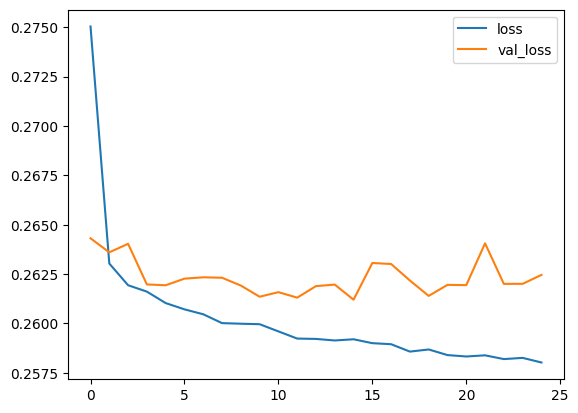

In [100]:
losses = pd.DataFrame(model.history.history)
losses.plot()

In [101]:
from sklearn.metrics import classification_report, confusion_matrix

In [102]:
predictions = model.predict(X_test)
predictions = (predictions >= 0.5).astype(int)

2471/2471 [==============================] - 2s 747us/step


In [103]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.43      0.60     15658
           1       0.88      1.00      0.93     63386

    accuracy                           0.89     79044
   macro avg       0.94      0.71      0.77     79044
weighted avg       0.90      0.89      0.87     79044



In [104]:
print(confusion_matrix(y_test, predictions))

[[ 6724  8934]
 [    4 63382]]


In [105]:
df['loan_repaid'].value_counts()

loan_repaid
1    317696
0     77523
Name: count, dtype: int64

In [106]:
317696/len(df)

0.8038479931379817

In [107]:
import random
random.seed(101)
random_ind = random.randint(0,len(df))

new_customer = df.drop('loan_repaid',axis=1).iloc[random_ind]
new_customer

loan_amnt           25000.0
term                     60
int_rate              18.24
installment          638.11
annual_inc          61665.0
                     ...   
zipcode_48052         False
zipcode_70466         False
zipcode_86630         False
zipcode_93700         False
earliest_cr_year       1996
Name: 305323, Length: 78, dtype: object

In [108]:
new_customer = scaler.transform(new_customer.values.reshape(1,78))

In [109]:
new_cus_pred = model.predict(new_customer)
new_customer_pred = (new_cus_pred >= 0.5).astype(int)
new_customer_pred

1/1 [==============================] - 0s 23ms/step


array([[1]])

In [110]:
df.iloc[random_ind]['loan_repaid']

1

Logistic Regression


In [111]:
from sklearn.linear_model import LogisticRegression

In [112]:
logmodel = LogisticRegression(max_iter=1000)

In [113]:
logmodel.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [114]:
log_model_predictions = logmodel.predict(X_test)

In [115]:
print(classification_report(y_test,log_model_predictions))

              precision    recall  f1-score   support

           0       0.97      0.45      0.61     15658
           1       0.88      1.00      0.93     63386

    accuracy                           0.89     79044
   macro avg       0.92      0.72      0.77     79044
weighted avg       0.90      0.89      0.87     79044



In [116]:
confusion_matrix(y_test,log_model_predictions)

array([[ 7040,  8618],
       [  254, 63132]], dtype=int64)

In [117]:
new_cus_pred = logmodel.predict(new_customer)
new_customer_pred = (new_cus_pred >= 0.5).astype(int)
new_customer_pred

array([1])

Random Forest Classifier

In [118]:
from sklearn.ensemble import RandomForestClassifier

In [119]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=101)

In [120]:
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=101)

In [121]:
random_forest_model_predictions = random_forest_model.predict(X_test)

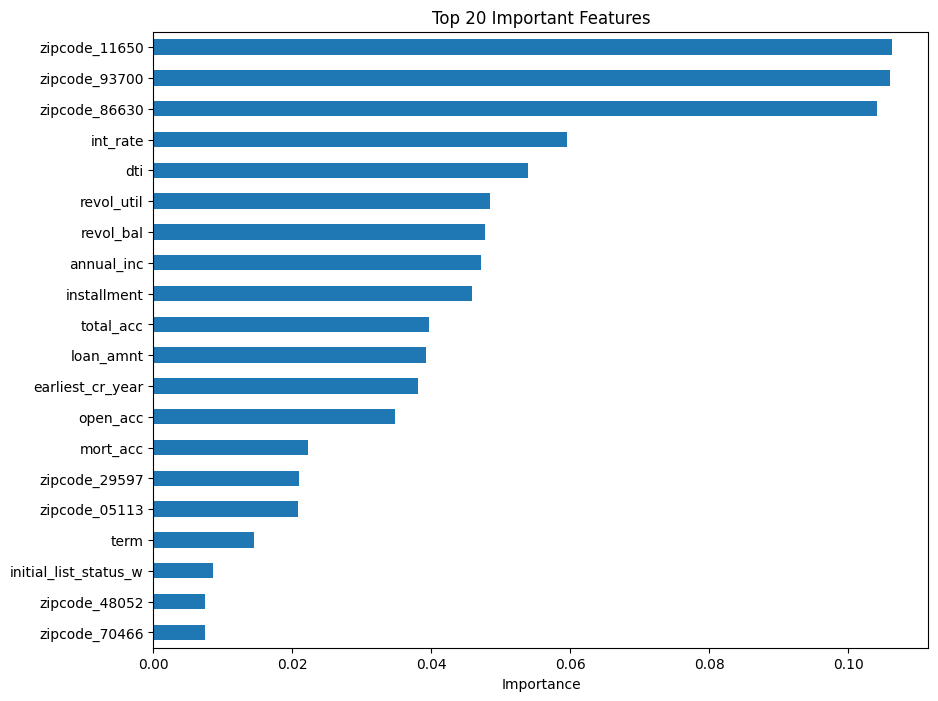

In [122]:
importance = pd.Series(
    random_forest_model.feature_importances_,
    index= df.columns.drop('loan_repaid')
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(20).plot(kind='barh')

plt.title("Top 20 Important Features")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()


In [123]:
print(classification_report(y_test,random_forest_model_predictions))

              precision    recall  f1-score   support

           0       0.95      0.46      0.62     15658
           1       0.88      0.99      0.93     63386

    accuracy                           0.89     79044
   macro avg       0.92      0.73      0.78     79044
weighted avg       0.90      0.89      0.87     79044



In [124]:
print(confusion_matrix(y_test,random_forest_model_predictions))

[[ 7143  8515]
 [  338 63048]]


In [125]:
new_cus_pred = random_forest_model.predict(new_customer)
new_customer_pred = (new_cus_pred >= 0.5).astype(int)
new_customer_pred[0]

1

2471/2471 [==============================] - 2s 698us/step


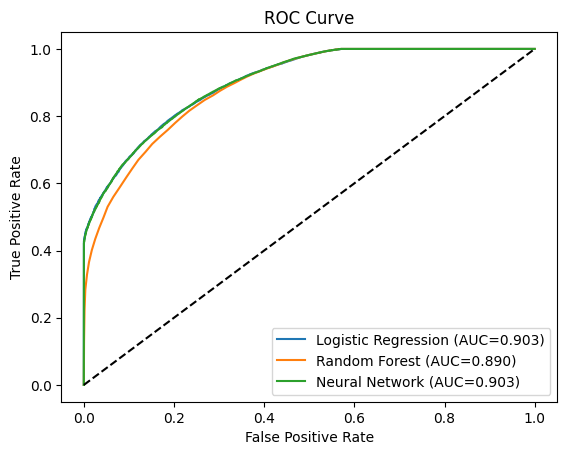

In [126]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression
y_prob_log = logmodel.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC={auc(fpr,tpr):.3f})')

# Random Forest
y_prob_rf = random_forest_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, label=f'Random Forest (AUC={auc(fpr,tpr):.3f})')

# Neural Network
y_prob_nn = model.predict(X_test).ravel()
fpr, tpr, _ = roc_curve(y_test, y_prob_nn)
plt.plot(fpr, tpr, label=f'Neural Network (AUC={auc(fpr,tpr):.3f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

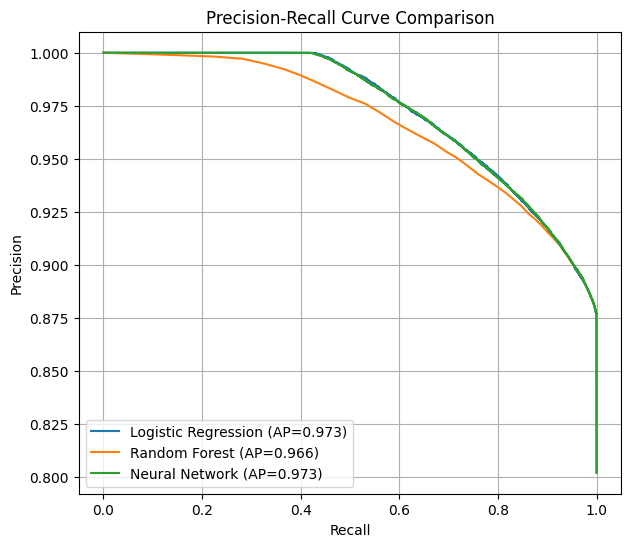

In [127]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7,6))
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_log
)
ap = average_precision_score(y_test, y_prob_log)
plt.plot(recall, precision,
         label=f'Logistic Regression (AP={ap:.3f})')


precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_rf
)
ap = average_precision_score(y_test, y_prob_rf)
plt.plot(recall, precision,
         label=f'Random Forest (AP={ap:.3f})')


precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_nn
)
ap = average_precision_score(y_test, y_prob_nn)
plt.plot(recall, precision,
         label=f'Neural Network (AP={ap:.3f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [128]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
log_pred = logmodel.predict(X_test)
rf_pred = random_forest_model.predict(X_test)
nn_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

# Probabilities
log_prob = logmodel.predict_proba(X_test)[:,1]
rf_prob = random_forest_model.predict_proba(X_test)[:,1]
nn_prob = model.predict(X_test).flatten()

comparison = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'Neural Network'
    ],

    'Accuracy':[
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, nn_pred)
    ],

    'Precision':[
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, nn_pred)
    ],

    'Recall':[
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, nn_pred)
    ],

    'F1 Score':[
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, nn_pred)
    ],

    'ROC-AUC':[
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, nn_prob)
    ]
})

comparison = comparison.round(4)

comparison

2471/2471 [==============================] - 2s 779us/step


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8878,0.8799,0.9960,0.9343,0.9028
1,Random Forest,0.8880,0.8810,0.9947,0.9344,0.8900
2,Neural Network,0.8869,0.8765,0.9999,0.9341,0.9027


In [129]:
comparison.style.highlight_max(
    subset=['Accuracy','Precision','Recall','F1 Score','ROC-AUC'],
    color='lightgreen'
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.887800,0.879900,0.996000,0.934300,0.902800
1,Random Forest,0.888000,0.881000,0.994700,0.934400,0.890000
2,Neural Network,0.886900,0.876500,0.999900,0.934100,0.902700


Conclusion

This project developed an end-to-end machine learning pipeline to predict loan repayment using historical Lending Club loan data. The workflow included data cleaning, exploratory data analysis, feature engineering, missing value handling, categorical encoding, feature scaling, and model training.

Three classification models—Logistic Regression, Random Forest, and a Neural Network—were trained and evaluated using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and Precision-Recall curves. The comparison showed that all three models achieved comparable performance, with accuracy close to 89% and F1-scores around 0.93.

The Neural Network achieved the highest ROC-AUC score (0.9034) and the highest recall, indicating a slightly better ability to distinguish between loan repayment classes. Random Forest produced the highest accuracy, precision, and F1-score, although the improvements over the other models were marginal. These results suggest that all three approaches are effective for loan repayment prediction, with model selection depending on the desired balance between recall, precision, and overall discrimination ability.

Feature importance analysis and exploratory data analysis indicated that variables such as loan amount, interest rate, annual income, debt-to-income ratio, and credit grade play an important role in predicting loan repayment behaviour. Overall, this project demonstrates how machine learning can support credit risk assessment by enabling financial institutions to identify high-risk loan applications and make more informed lending decisions.

Business Insights

• Borrowers with higher interest rates showed a greater likelihood of default.

• Lower credit grades were associated with increased default risk.

• Higher debt-to-income ratios negatively impacted repayment probability.

• Annual income demonstrated a positive relationship with successful loan repayment.

These findings can assist financial institutions in improving credit risk assessment and making informed lending decisions.